# Veridi Logistics Delivery Audit

In [3]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

In [4]:
orders = pd.read_csv(
    'olist_orders_dataset.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

reviews = pd.read_csv(
    'olist_order_reviews_dataset.csv',
    parse_dates=['review_creation_date', 'review_answer_timestamp']
)

customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

print('orders:', orders.shape)
print('reviews:', reviews.shape)
print('customers:', customers.shape)
print('products:', products.shape)

orders: (99441, 8)
reviews: (99224, 7)
customers: (99441, 5)
products: (32951, 9)


In [5]:
print('Unique order_id in orders:', orders['order_id'].nunique())
print('Duplicate order_id rows in orders:', orders.duplicated('order_id').sum())
print('Duplicate order_id rows in reviews:', reviews.duplicated('order_id').sum())
print('Duplicate customer_id rows in customers:', customers.duplicated('customer_id').sum())

Unique order_id in orders: 99441
Duplicate order_id rows in orders: 0
Duplicate order_id rows in reviews: 551
Duplicate customer_id rows in customers: 0


In [6]:
reviews_dedup = (
    reviews.sort_values('review_answer_timestamp')
           .drop_duplicates(subset=['order_id'], keep='last')
           .copy()
)

master = (
    orders.merge(reviews_dedup, on='order_id', how='left', validate='one_to_one')
          .merge(customers, on='customer_id', how='left', validate='many_to_one')
)

print('master shape:', master.shape)
print('master unique order_id:', master['order_id'].nunique())
print('expected order_id:', orders['order_id'].nunique())

if master['order_id'].nunique() != orders['order_id'].nunique():
    print('Warning: order_id uniqueness changed after join')
else:
    print('Join check passed: no order_id duplication introduced')

master.head(3)

master shape: (99441, 18)
master unique order_id: 99441
expected order_id: 99441
Join check passed: no order_id duplication introduced


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


# Real Delay Calculator

In [7]:
master2 = master.copy()

master2['exclude_reason'] = pd.Series(pd.NA, index=master2.index, dtype='object')
master2.loc[master2['order_status'].isin(['canceled', 'unavailable']), 'exclude_reason'] = 'not_delivered_status'
master2.loc[
    master2['exclude_reason'].isna() & master2['order_delivered_customer_date'].isna(),
    'exclude_reason'
] = 'missing_delivery_date'

print('Total orders:', len(master2))
print('Excluded orders:', master2['exclude_reason'].notna().sum())
print('\nExclude reasons:')
print(master2['exclude_reason'].value_counts(dropna=False))

Total orders: 99441
Excluded orders: 2971

Exclude reasons:
exclude_reason
<NA>                     96470
missing_delivery_date     1737
not_delivered_status      1234
Name: count, dtype: int64


In [8]:
analysis = master2[
    (master2['exclude_reason'].isna()) &
    (master2['order_delivered_customer_date'].notna()) &
    (master2['order_estimated_delivery_date'].notna())
].copy()

analysis['Days_Difference'] = (
    analysis['order_estimated_delivery_date'] - analysis['order_delivered_customer_date']
).dt.total_seconds() / 86400

print('Orders included in delay analysis:', len(analysis))
analysis[['order_id', 'order_status', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'Days_Difference']].head(5)

Orders included in delay analysis: 96470


,order_id,order_status,order_estimated_delivery_date,order_delivered_customer_date,Days_Difference
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-18,2017-10-10 21:25:13,7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-08-13,2018-08-07 15:27:45,5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-09-04,2018-08-17 18:06:29,17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-12-15,2017-12-02 00:28:42,12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-26,2018-02-16 18:17:02,9.238171


In [9]:
analysis['delivery_status'] = np.select(
    [
        analysis['Days_Difference'] >= 0,
        (analysis['Days_Difference'] < 0) & (analysis['Days_Difference'] >= -5),
        analysis['Days_Difference'] < -5
    ],
    [
        'On Time',
        'Late',
        'Super Late'
    ],
    default='Unknown'
)

print('Delivery status distribution:')
print(analysis['delivery_status'].value_counts())

print('\nDelivery status share (%):')
print((analysis['delivery_status'].value_counts(normalize=True) * 100).round(2))

Delivery status distribution:
delivery_status
On Time       88644
Super Late     4211
Late           3615
Name: count, dtype: int64

Delivery status share (%):
delivery_status
On Time       91.89
Super Late     4.37
Late           3.75
Name: proportion, dtype: float64


In [10]:
print('Days_Difference summary:')
print(analysis['Days_Difference'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print('\nSample of super late orders (more than 5 days late):')
sample_super_late = analysis[analysis['delivery_status'] == 'Super Late'][[
    'order_id',
    'customer_state',
    'order_estimated_delivery_date',
    'order_delivered_customer_date',
    'Days_Difference',
    'review_score'
]].head(10)
print(sample_super_late)

Days_Difference summary:
count    96470.000000
mean        11.178126
std         10.184354
min       -188.975081
1%         -18.939553
5%          -3.816993
50%         11.948102
95%         25.939634
99%         35.144500
max        146.016123
Name: Days_Difference, dtype: float64

Sample of super late orders (more than 5 days late):
                             order_id customer_state order_estimated_delivery_date order_delivered_customer_date  Days_Difference  \
20   203096f03d82e0dffbc41ebc2e2bcfb7             SP                    2017-09-28           2017-10-09 22:23:46       -11.933171   
25   fbf9ac61453ac646ce8ad9783d7d0af6             RJ                    2018-03-12           2018-03-21 22:03:54        -9.919375   
41   6ea2f835b4556291ffdc53fa0b3b95e8             SP                    2017-12-21           2017-12-28 18:59:23        -7.791238   
58   a685d016c8a26f71a0bb67821070e398             SP                    2017-03-30           2017-04-06 13:37:16        -7.567546  

In [11]:
master_delivery = analysis.copy()
print('master_delivery shape:', master_delivery.shape)

master_delivery shape: (96470, 21)


# Geographic Heatmap

In [12]:
import plotly.express as px

geo = master_delivery.copy()
geo['is_late'] = geo['delivery_status'].isin(['Late', 'Super Late']).astype(int)

state_metrics = (
    geo.groupby('customer_state')
       .agg(
           total_orders=('order_id', 'count'),
           late_orders=('is_late', 'sum'),
           avg_review_score=('review_score', 'mean')
       )
       .reset_index()
)

state_metrics['late_pct'] = (state_metrics['late_orders'] / state_metrics['total_orders']) * 100
state_metrics = state_metrics.sort_values('late_pct', ascending=False)

print('Top 10 states by late delivery rate:')
print(state_metrics[['customer_state', 'total_orders', 'late_orders', 'late_pct', 'avg_review_score']].head(10))

Top 10 states by late delivery rate:
   customer_state  total_orders  late_orders   late_pct  avg_review_score
1              AL           397           95  23.929471          3.847716
9              MA           717          141  19.665272          3.832865
16             PI           476           76  15.966387          3.993631
5              CE          1279          196  15.324472          3.944226
24             SE           335           51  15.223881          3.907186
4              BA          3256          457  14.035627          3.930629
18             RJ         12350         1664  13.473684          3.965441
26             TO           274           35  12.773723          4.153846
13             PA           946          117  12.367865          3.914255
7              ES          1995          244  12.230576          4.078720


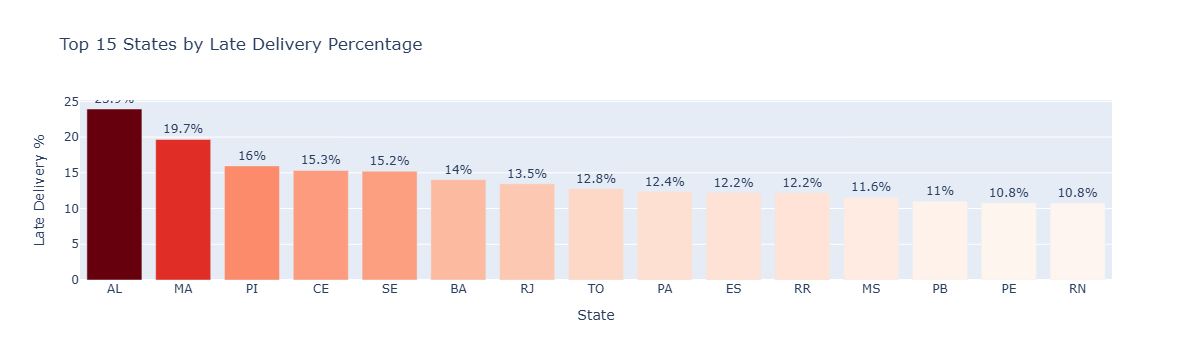

In [13]:
fig_state_bar = px.bar(
    state_metrics.head(15),
    x='customer_state',
    y='late_pct',
    color='late_pct',
    color_continuous_scale='Reds',
    text=state_metrics.head(15)['late_pct'].round(1),
    title='Top 15 States by Late Delivery Percentage',
    labels={'customer_state': 'State', 'late_pct': 'Late Delivery %'}
)
fig_state_bar.update_traces(texttemplate='%{text}%', textposition='outside')
fig_state_bar.update_layout(yaxis_title='Late Delivery %', xaxis_title='State', coloraxis_showscale=False)
fig_state_bar.show()

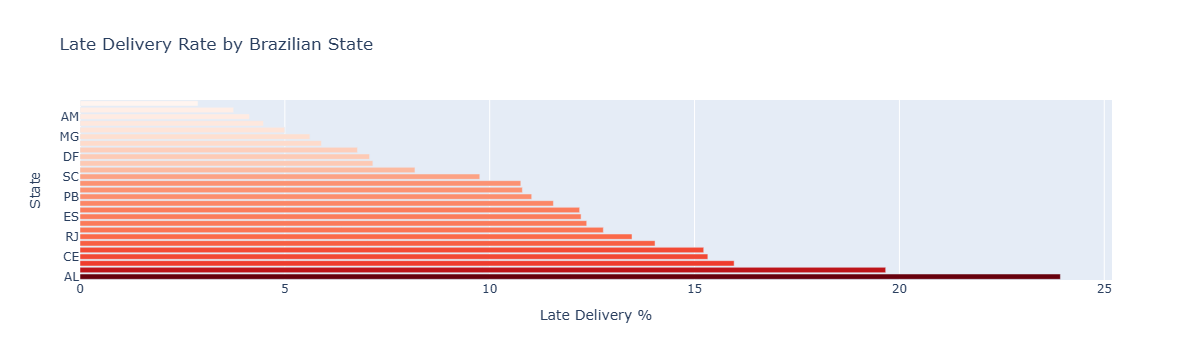

In [14]:
fig_state_rank = px.bar(
    state_metrics.sort_values('late_pct', ascending=False),
    x='late_pct',
    y='customer_state',
    orientation='h',
    color='late_pct',
    color_continuous_scale='Reds',
    hover_data={
        'total_orders': True,
        'late_orders': True,
        'late_pct': ':.2f',
        'avg_review_score': ':.2f'
    },
    title='Late Delivery Rate by Brazilian State'
)
fig_state_rank.update_layout(
    xaxis_title='Late Delivery %',
    yaxis_title='State',
    coloraxis_showscale=False
)
fig_state_rank.show()

In [15]:
best_states = state_metrics.tail(5)[['customer_state', 'late_pct']].sort_values('late_pct')
worst_states = state_metrics.head(5)[['customer_state', 'late_pct']]

print('Worst 5 states by late delivery rate:')
print(worst_states)
print('\nBest 5 states by late delivery rate:')
print(best_states)

Worst 5 states by late delivery rate:
   customer_state   late_pct
1              AL  23.929471
9              MA  19.665272
16             PI  15.966387
5              CE  15.324472
24             SE  15.223881

Best 5 states by late delivery rate:
   customer_state  late_pct
20             RO  2.880658
0              AC  3.750000
2              AM  4.137931
3              AP  4.477612
17             PR  4.996953


# Sentiment Correlation

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sentiment = master_delivery.copy()

sentiment = sentiment[sentiment['review_score'].notna()].copy()

sentiment['delay_days'] = sentiment['Days_Difference']

print('Rows with review scores:', len(sentiment))
print(sentiment[['delay_days', 'review_score']].describe())

Rows with review scores: 95824
         delay_days  review_score
count  95824.000000   95824.00000
mean      11.215213       4.15588
std       10.114097       1.28481
min     -188.975081       1.00000
25%        6.407182       4.00000
50%       11.973050       5.00000
75%       16.248435       5.00000
max      146.016123       5.00000


In [17]:
!pip install statsmodels==0.14.6

[notice] A new release of pip is available: 25.3 -> 26.0.1


[notice] To update, run: python.exe -m pip install --upgrade pip

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 541.5 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/9.5 MB 541.5 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/9.5 MB 584.3 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/9.5 MB 584.3 kB/s eta 0:00:15
   ---- ----------------------------------- 1.0/9.5 MB 639.4 kB/s eta 0:00:14
   ----- ---------------------------------- 1.3/9.5 MB 688.6 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9

In [19]:
fig_scatter = px.scatter(
    sentiment,
    x='delay_days',
    y='review_score',
    trendline='ols',
    opacity=0.25,
    title='Delivery Delay vs Average Review Score',
    labels={'delay_days': 'Delivery Delay (Days)', 'review_score': 'Review Score (1-5)'}
)
fig_scatter.update_layout(yaxis=dict(dtick=1))
fig_scatter.show()

ImportError: cannot import name 'PD_LT_3' from 'statsmodels.compat.pandas' (C:\Users\GIGACHAD\anaconda3\Lib\site-packages\statsmodels\compat\pandas.py)

  delivery_bucket  avg_review_score  order_count
0            Late          2.565070         7661
1         On Time          4.294114        88163


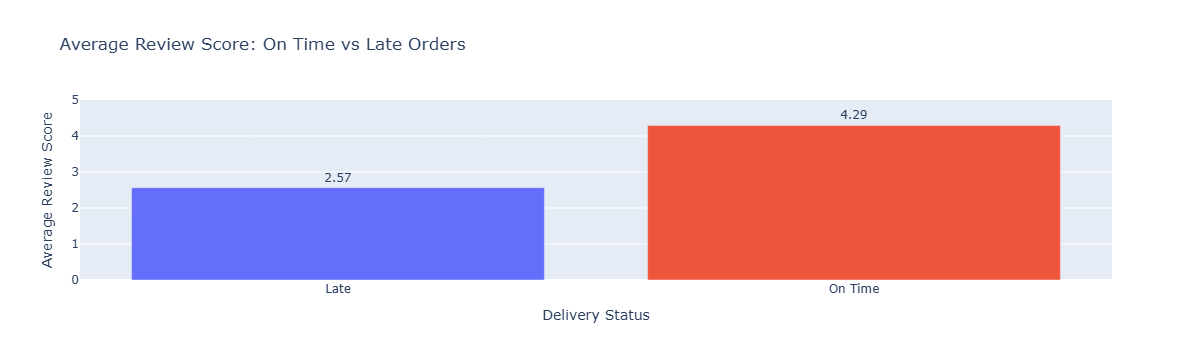

In [20]:
sentiment['delivery_bucket'] = np.where(
    sentiment['delivery_status'] == 'On Time',
    'On Time',
    'Late'
)

bucket_scores = (
    sentiment.groupby('delivery_bucket')
             .agg(
                 avg_review_score=('review_score', 'mean'),
                 order_count=('order_id', 'count')
             )
             .reset_index()
)

print(bucket_scores)

fig_bucket = px.bar(
    bucket_scores,
    x='delivery_bucket',
    y='avg_review_score',
    color='delivery_bucket',
    text=bucket_scores['avg_review_score'].round(2),
    title='Average Review Score: On Time vs Late Orders',
    labels={'delivery_bucket': 'Delivery Status', 'avg_review_score': 'Average Review Score'}
)
fig_bucket.update_traces(textposition='outside')
fig_bucket.update_layout(showlegend=False, yaxis_range=[0, 5])
fig_bucket.show()

# Bonus: Promise Accuracy Risk Monitor

In [21]:
bonus = master_delivery.copy()

bonus['delay_days'] = bonus['Days_Difference']

state_risk = (
    bonus.groupby('customer_state')
         .agg(
             orders=('order_id', 'count'),
             avg_delay_days=('delay_days', 'mean'),
             p90_delay_days=('delay_days', lambda s: s.quantile(0.10)),
             late_rate=('delivery_status', lambda s: (s.isin(['Late', 'Super Late']).mean()) * 100),
             avg_review=('review_score', 'mean')
         )
         .reset_index()
)


state_risk['promise_risk'] = np.select(
    [
        state_risk['avg_delay_days'] < 0,
        (state_risk['avg_delay_days'] >= 0) & (state_risk['avg_delay_days'] <= 8),
        state_risk['avg_delay_days'] > 8
    ],
    [
        'Over-promising risk',
        'Balanced promise',
        'Conservative promise'
    ],
    default='Unknown'
)

print('State promise-risk snapshot (top 12 by late rate):')
print(
    state_risk.sort_values('late_rate', ascending=False)[
        ['customer_state', 'orders', 'late_rate', 'avg_delay_days', 'p90_delay_days', 'avg_review', 'promise_risk']
    ].head(12)
)

State promise-risk snapshot (top 12 by late rate):
   customer_state  orders  late_rate  avg_delay_days  p90_delay_days  avg_review          promise_risk
1              AL     397  23.929471        8.032059       -8.189868    3.847716  Conservative promise
9              MA     717  19.665272        8.887844       -6.691979    3.832865  Conservative promise
16             PI     476  15.966387       10.629538       -3.807558    3.993631  Conservative promise
5              CE    1279  15.324472       10.110007       -6.712856    3.944226  Conservative promise
24             SE     335  15.223881        9.328641       -7.508525    3.907186  Conservative promise
4              BA    3256  14.035627       10.099073       -3.583594    3.930629  Conservative promise
18             RJ   12350  13.473684       11.054735       -3.795111    3.965441  Conservative promise
26             TO     274  12.773723       11.439738       -0.975888    4.153846  Conservative promise
13             PA     

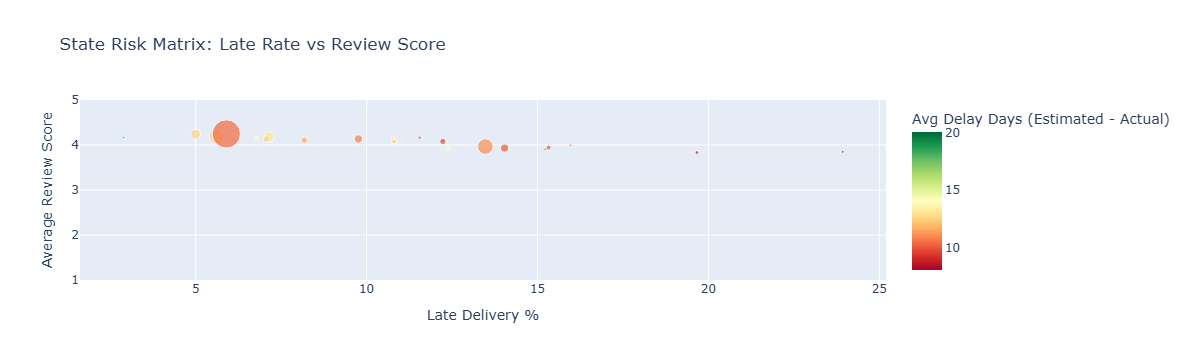

In [22]:
fig_risk = px.scatter(
    state_risk,
    x='late_rate',
    y='avg_review',
    size='orders',
    color='avg_delay_days',
    hover_name='customer_state',
    color_continuous_scale='RdYlGn',
    title='State Risk Matrix: Late Rate vs Review Score',
    labels={
        'late_rate': 'Late Delivery %',
        'avg_review': 'Average Review Score',
        'avg_delay_days': 'Avg Delay Days (Estimated - Actual)'
    }
)
fig_risk.update_layout(yaxis_range=[1, 5])
fig_risk.show()

In [23]:
priority_states = state_risk[
    (state_risk['late_rate'] >= state_risk['late_rate'].quantile(0.75)) &
    (state_risk['avg_review'] <= state_risk['avg_review'].quantile(0.35))
].sort_values(['late_rate', 'avg_review'], ascending=[False, True])

print('Priority states for intervention:')
print(priority_states[['customer_state', 'orders', 'late_rate', 'avg_review', 'avg_delay_days', 'promise_risk']])

bonus_priority_states = priority_states.copy()

Priority states for intervention:
   customer_state  orders  late_rate  avg_review  avg_delay_days          promise_risk
1              AL     397  23.929471    3.847716        8.032059  Conservative promise
9              MA     717  19.665272    3.832865        8.887844  Conservative promise
16             PI     476  15.966387    3.993631       10.629538  Conservative promise
5              CE    1279  15.324472    3.944226       10.110007  Conservative promise
24             SE     335  15.223881    3.907186        9.328641  Conservative promise
4              BA    3256  14.035627    3.930629       10.099073  Conservative promise
18             RJ   12350  13.473684    3.965441       11.054735  Conservative promise


# Export Data for Dashboard

In [24]:
state_dashboard = state_metrics.copy()

sentiment_dashboard = bucket_scores.copy()

priority_dashboard = bonus_priority_states.copy()

state_status_breakdown = (
    master_delivery.groupby(['customer_state', 'delivery_status'])
    .size()
    .reset_index(name='orders')
)

state_delay_stats = (
    master_delivery.groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        median_delay_days=('Days_Difference', 'median'),
        p90_late_cut=('Days_Difference', lambda s: s.quantile(0.10))
    )
    .reset_index()
)

print('state_dashboard:', state_dashboard.shape)
print('sentiment_dashboard:', sentiment_dashboard.shape)
print('priority_dashboard:', priority_dashboard.shape)
print('state_status_breakdown:', state_status_breakdown.shape)
print('state_delay_stats:', state_delay_stats.shape)

state_dashboard: (27, 5)
sentiment_dashboard: (2, 3)
priority_dashboard: (7, 7)
state_status_breakdown: (80, 3)
state_delay_stats: (27, 4)


In [25]:
state_dashboard.to_csv('dashboard_state_metrics.csv', index=False)
sentiment_dashboard.to_csv('dashboard_sentiment_summary.csv', index=False)
priority_dashboard.to_csv('dashboard_priority_states.csv', index=False)
state_status_breakdown.to_csv('dashboard_state_status_breakdown.csv', index=False)
state_delay_stats.to_csv('dashboard_state_delay_stats.csv', index=False)

print('Export complete. Files created in project folder:')
print('- dashboard_state_metrics.csv')
print('- dashboard_sentiment_summary.csv')
print('- dashboard_priority_states.csv')
print('- dashboard_state_status_breakdown.csv')
print('- dashboard_state_delay_stats.csv')

Export complete. Files created in project folder:
- dashboard_state_metrics.csv
- dashboard_sentiment_summary.csv
- dashboard_priority_states.csv
- dashboard_state_status_breakdown.csv
- dashboard_state_delay_stats.csv


In [26]:
overall_kpi = pd.DataFrame({
    'metric': [
        'Total analyzed orders',
        'On time %',
        'Late %',
        'Super late %',
        'Avg review score',
        'Excluded orders'
    ],
    'value': [
        len(master_delivery),
        (master_delivery['delivery_status'].eq('On Time').mean() * 100),
        (master_delivery['delivery_status'].eq('Late').mean() * 100),
        (master_delivery['delivery_status'].eq('Super Late').mean() * 100),
        master_delivery['review_score'].mean(),
        master2['exclude_reason'].notna().sum()
    ]
})

overall_kpi.to_csv('dashboard_overall_kpi.csv', index=False)
print(overall_kpi)

                  metric         value
0  Total analyzed orders  96470.000000
1              On time %     91.887633
2                 Late %      3.747279
3           Super late %      4.365088
4       Avg review score      4.155880
5        Excluded orders   2971.000000


# Product Category Translation \(Portuguese \-\> English\)

In [27]:
import os

required_files = [
    'olist_order_items_dataset.csv',
    'product_category_name_translation.csv'
]

missing = [f for f in required_files if not os.path.exists(f)]

if missing:
    print('Missing files:', missing)
    print('Upload these files to Deepnote before continuing this step.')
else:
    print('All required files are present.')

All required files are present.


In [28]:
order_items = pd.read_csv('olist_order_items_dataset.csv')
cat_translation = pd.read_csv('product_category_name_translation.csv')

print('order_items:', order_items.shape)
print('cat_translation:', cat_translation.shape)
print(cat_translation.head(3))

order_items: (112650, 7)
cat_translation: (71, 2)
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto


In [29]:
prod_cat = products[['product_id', 'product_category_name']].copy()

items_with_cat = (
    order_items
    .merge(prod_cat, on='product_id', how='left')
    .merge(
        cat_translation,
        on='product_category_name',
        how='left'
    )
)

category_audit = items_with_cat.merge(
    master_delivery[[
        'order_id',
        'customer_state',
        'delivery_status',
        'Days_Difference',
        'review_score'
    ]],
    on='order_id',
    how='inner'
)

category_audit['category_en'] = category_audit['product_category_name_english'].fillna(
    category_audit['product_category_name']
)

print('category_audit shape:', category_audit.shape)
print('Null category_en:', category_audit['category_en'].isna().sum())
category_audit[['order_id', 'product_id', 'product_category_name', 'category_en', 'delivery_status']].head(5)

category_audit shape: (110189, 14)
Null category_en: 1537


,order_id,product_id,product_category_name,category_en,delivery_status
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff,On Time
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop,On Time
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor,On Time
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery,On Time
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools,On Time


In [30]:
category_perf = (
    category_audit
    .groupby('category_en')
    .agg(
        item_rows=('order_id', 'count'),
        unique_orders=('order_id', 'nunique'),
        late_pct=('delivery_status', lambda s: (s.isin(['Late', 'Super Late']).mean()) * 100),
        avg_delay_days=('Days_Difference', 'mean'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

category_perf_filtered = category_perf[category_perf['unique_orders'] >= 100].copy()

print('Top 15 categories by late % (min 100 orders):')
print(
    category_perf_filtered
    .sort_values('late_pct', ascending=False)
    [['category_en', 'unique_orders', 'late_pct', 'avg_delay_days', 'avg_review']]
    .head(15)
)

Top 15 categories by late % (min 100 orders):
                  category_en  unique_orders   late_pct  avg_delay_days  avg_review
4                       audio            348  12.707182        9.466330    3.837989
33    fashion_underwear_beach            117  12.598425       10.210535    4.047619
12         christmas_supplies            125  12.000000       11.328950    4.069930
10            books_technical            256  11.026616       10.601557    4.389313
47               home_confort            392  10.256410        9.114846    3.852459
18  construction_tools_lights            242   9.966777       10.507701    4.082192
36                       food            441   9.819639        9.179071    4.262834
26                electronics           2517   9.747160       10.434594    4.067159
43              health_beauty           8647   9.054411       11.267750    4.189534
57           office_furniture           1254   8.932854       11.153240    3.516324
6                        baby 

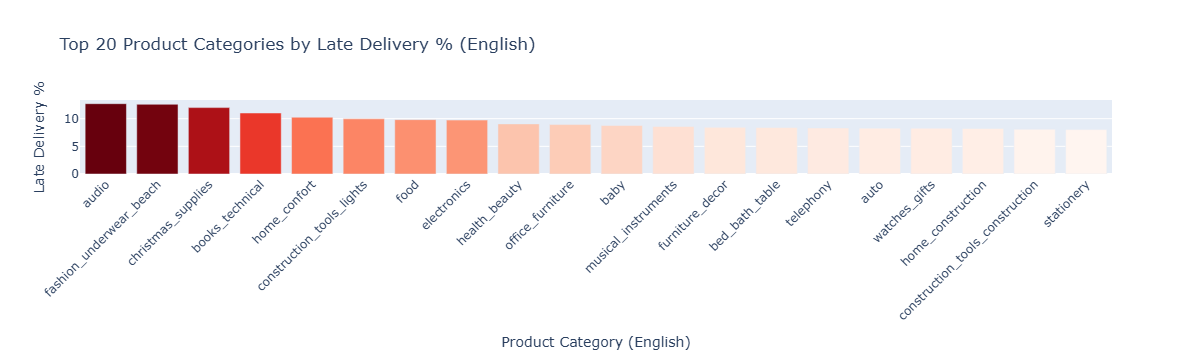

In [31]:
fig_cat = px.bar(
    category_perf_filtered.sort_values('late_pct', ascending=False).head(20),
    x='category_en',
    y='late_pct',
    color='late_pct',
    color_continuous_scale='Reds',
    title='Top 20 Product Categories by Late Delivery % (English)',
    labels={'category_en': 'Product Category (English)', 'late_pct': 'Late Delivery %'}
)
fig_cat.update_layout(xaxis_tickangle=-45, coloraxis_showscale=False)
fig_cat.show()

Furniture vs Electronics summary:
        group_focus  categories  total_orders  weighted_late_pct  avg_review
0  Electronics/Tech           6         13876           8.233687    3.977341
1    Furniture/Home           9         19337           7.798925    3.949597


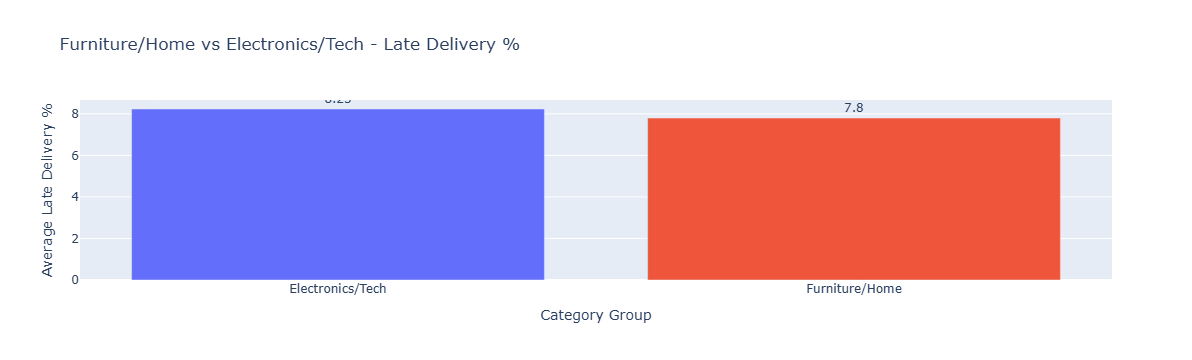

In [32]:
category_perf_filtered['group_focus'] = np.select(
    [
        category_perf_filtered['category_en'].str.contains('furniture|bed_bath_table|home', case=False, na=False),
        category_perf_filtered['category_en'].str.contains('electronics|computers|audio|telephony', case=False, na=False)
    ],
    ['Furniture/Home', 'Electronics/Tech'],
    default='Other'
)

focus = category_perf_filtered[category_perf_filtered['group_focus'].isin(['Furniture/Home', 'Electronics/Tech'])]

focus_summary = (
    focus.groupby('group_focus')
    .agg(
        categories=('category_en', 'nunique'),
        total_orders=('unique_orders', 'sum'),
        weighted_late_pct=('late_pct', 'mean'),
        avg_review=('avg_review', 'mean')
    )
    .reset_index()
)

print('Furniture vs Electronics summary:')
print(focus_summary)

fig_focus = px.bar(
    focus_summary,
    x='group_focus',
    y='weighted_late_pct',
    color='group_focus',
    text=focus_summary['weighted_late_pct'].round(2),
    title='Furniture/Home vs Electronics/Tech - Late Delivery %',
    labels={'group_focus': 'Category Group', 'weighted_late_pct': 'Average Late Delivery %'}
)
fig_focus.update_traces(textposition='outside')
fig_focus.update_layout(showlegend=False)
fig_focus.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=70856a3f-44f4-4d1e-923d-8838411dc434' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>